# Walmart Sales Forecasting Project

# Notebook 07 – Model Evaluation

## Objective

Evaluate all trained machine learning models using regression metrics and select the best-performing model for future sales forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("../data/processed/sales_feature_engineered.xlsx")

In [3]:
df.head()

,Order Date,Sales,Year,Quarter,Month,Week,Day,DayOfWeek,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30,Rolling_STD_7,Expanding_Mean,Month_Sin,Month_Cos,Day_Sin,Day_Cos
0,2011-02-06,0.00,2011,1,2,5,6,6,1,134.384,0.000,19.44,76.358857,105.437633,109.021650,102.663516,0.866025,0.5,-0.781831,0.623490
1,2011-02-07,0.00,2011,1,2,6,7,0,0,0.000,0.000,0.00,76.358857,105.437633,109.021650,99.455281,0.866025,0.5,0.000000,1.000000
2,2011-02-08,0.00,2011,1,2,6,8,1,0,0.000,290.666,0.00,34.835143,105.437633,56.491758,96.441485,0.866025,0.5,0.781831,0.623490
3,2011-02-09,14.56,2011,1,2,6,9,2,0,0.000,0.000,0.00,36.915143,105.922967,55.249769,94.033206,0.866025,0.5,0.974928,-0.222521
4,2011-02-10,0.00,2011,1,2,6,10,3,0,14.560,12.350,0.00,35.150857,105.922967,56.351152,91.346543,0.866025,0.5,0.433884,-0.900969


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order Date       1425 non-null   datetime64[us]
 1   Sales            1425 non-null   float64       
 2   Year             1425 non-null   int64         
 3   Quarter          1425 non-null   int64         
 4   Month            1425 non-null   int64         
 5   Week             1425 non-null   int64         
 6   Day              1425 non-null   int64         
 7   DayOfWeek        1425 non-null   int64         
 8   IsWeekend        1425 non-null   int64         
 9   Lag_1            1425 non-null   float64       
 10  Lag_7            1425 non-null   float64       
 11  Lag_30           1425 non-null   float64       
 12  Rolling_Mean_7   1425 non-null   float64       
 13  Rolling_Mean_30  1425 non-null   float64       
 14  Rolling_STD_7    1425 non-null   float64       
 15

In [7]:
X = df.drop(columns=["Order Date", "Sales", "DayName"], errors="ignore")
y = df["Sales"]

In [8]:
print(X.shape)
print(y.shape)

(1425, 18)
(1425,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(1140, 18)
(285, 18)


In [11]:
lr_model = joblib.load("../models/linear_regression.pkl")
rf_model = joblib.load("../models/random_forest.pkl")

In [12]:
print("Models loaded successfully!")

Models loaded successfully!


In [13]:
# Baseline Model (Previous Day's Sales)
baseline_prediction = X_test["Lag_1"]

# Linear Regression Predictions
lr_predictions = lr_model.predict(X_test)

# Random Forest Predictions
rf_predictions = rf_model.predict(X_test)

In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2 Score": r2
    }

In [15]:
results = []

results.append(
    evaluate_model(
        "Baseline",
        y_test,
        baseline_prediction
    )
)

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

In [16]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,MAPE,R2 Score
0,Baseline,1145.519484,4.067722e+06,2016.859328,1.088568e+18,-1.104772
1,Linear Regression,778.454024,1.545230e+06,1243.072821,7.832557e+17,0.200447
2,Random Forest,992.659382,1.896166e+06,1377.013528,1.187952e+18,0.018862


In [17]:
results_df.to_excel(
    "../data/processed/model_evaluation.xlsx",
    index=False
)

print("✅ model_evaluation.xlsx saved successfully!")

✅ model_evaluation.xlsx saved successfully!


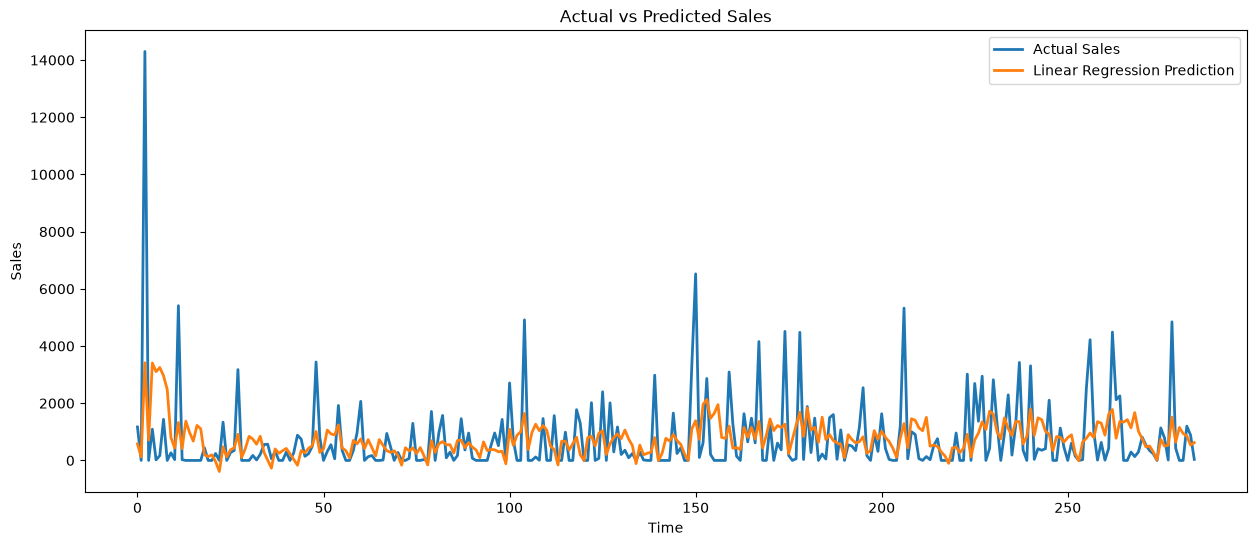

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    lr_predictions,
    label="Linear Regression Prediction",
    linewidth=2
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()

plt.show()

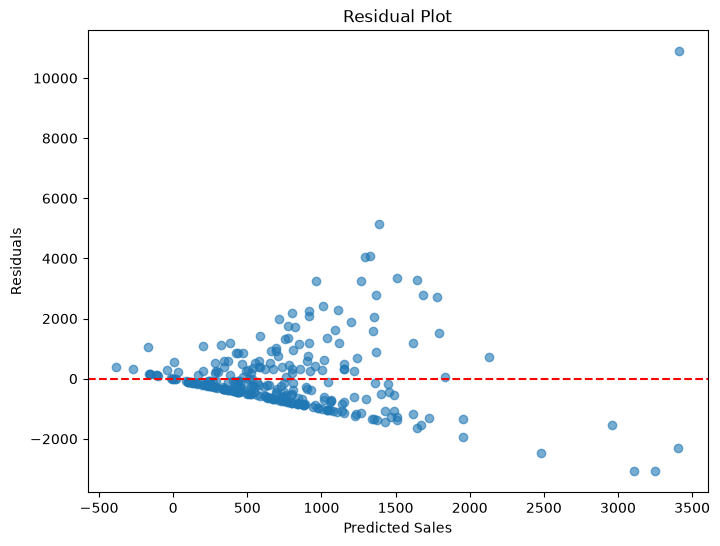

In [19]:
residuals = y_test - lr_predictions

plt.figure(figsize=(8,6))

plt.scatter(
    lr_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# Business Conclusion

- Three forecasting models were evaluated:
  - Baseline Model
  - Linear Regression
  - Random Forest

- Linear Regression achieved the lowest RMSE and the highest R² score.

- Calendar-based and lag features improved forecasting performance.

- The model can be used to estimate future Walmart sales and support business planning.

- Further improvements can be achieved through hyperparameter tuning or advanced forecasting models such as XGBoost, LightGBM, or Prophet.